In [6]:
#Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les visualisations
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)


# I. Préparation du dataset

In [7]:

print("1.1 Importation du dataset")

df = pd.read_csv("seeds_dataset.csv")
print(f"Dataset importé avec succès: {df.shape[0]} lignes et {df.shape[1]} colonnes.")


1.1 Importation du dataset
Dataset importé avec succès: 210 lignes et 9 colonnes.



 Vérification des données du dataset

In [8]:
print("\n1.2 Vérification des données du dataset")
print("Informations sur le dataset:")
print(df.info())


1.2 Vérification des données du dataset
Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    210 non-null    int64  
 1   area                  210 non-null    float64
 2   perimeter             210 non-null    float64
 3   compactness           210 non-null    float64
 4   lengthOfKernel        210 non-null    float64
 5   widthOfKernel         210 non-null    float64
 6   asymmetryCoefficient  210 non-null    float64
 7   lengthOfKernelGroove  210 non-null    float64
 8   seedType              210 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 14.9 KB
None


In [9]:

print("\nDescription statistique des données numériques:")
print(df.describe())


Description statistique des données numériques:
               ID        area   perimeter  compactness  lengthOfKernel  \
count  210.000000  210.000000  210.000000   210.000000      210.000000   
mean   105.500000   14.847524   14.559286     0.870999        5.628533   
std     60.765944    2.909699    1.305959     0.023629        0.443063   
min      1.000000   10.590000   12.410000     0.808100        4.899000   
25%     53.250000   12.270000   13.450000     0.856900        5.262250   
50%    105.500000   14.355000   14.320000     0.873450        5.523500   
75%    157.750000   17.305000   15.715000     0.887775        5.979750   
max    210.000000   21.180000   17.250000     0.918300        6.675000   

       widthOfKernel  asymmetryCoefficient  lengthOfKernelGroove    seedType  
count     210.000000            210.000000            210.000000  210.000000  
mean        3.258605              3.700201              5.408071    2.000000  
std         0.377714              1.503557     

In [10]:
print("\nVérification des valeurs manquantes:")
print(df.isnull().sum())


Vérification des valeurs manquantes:
ID                      0
area                    0
perimeter               0
compactness             0
lengthOfKernel          0
widthOfKernel           0
asymmetryCoefficient    0
lengthOfKernelGroove    0
seedType                0
dtype: int64


In [11]:
# Affichage de quelques lignes du dataset
print("\nAperçu des premières lignes du dataset:")
print(df.head())


Aperçu des premières lignes du dataset:
   ID   area  perimeter  compactness  lengthOfKernel  widthOfKernel  \
0   1  15.26      14.84       0.8710           5.763          3.312   
1   2  14.88      14.57       0.8811           5.554          3.333   
2   3  14.29      14.09       0.9050           5.291          3.337   
3   4  13.84      13.94       0.8955           5.324          3.379   
4   5  16.14      14.99       0.9034           5.658          3.562   

   asymmetryCoefficient  lengthOfKernelGroove  seedType  
0                 2.221                 5.220         1  
1                 1.018                 4.956         1  
2                 2.699                 4.825         1  
3                 2.259                 4.805         1  
4                 1.355                 5.175         1  


 Répartition des classes


1.3 Répartition des classes


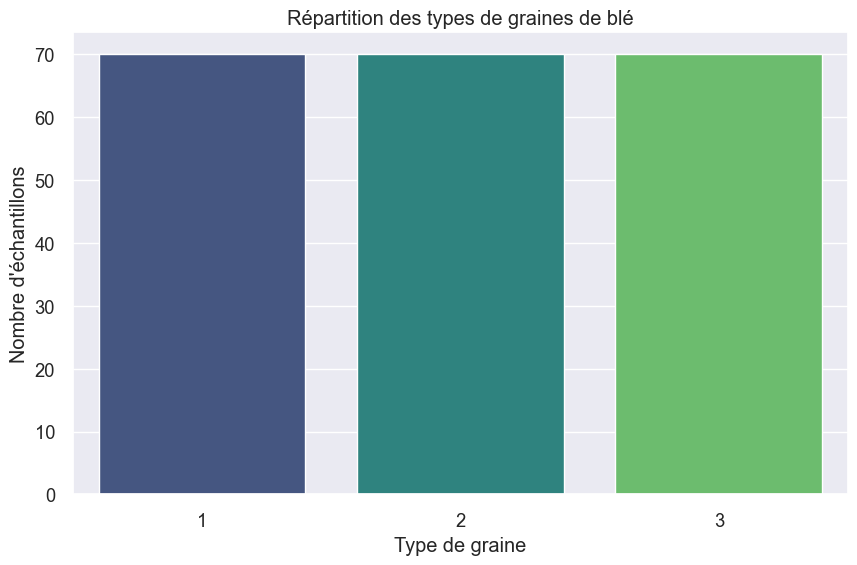

In [12]:
print("\n1.3 Répartition des classes")
plt.figure(figsize=(10, 6))
sns.countplot(x='seedType', data=df, palette='viridis')
plt.title('Répartition des types de graines de blé')
plt.xlabel('Type de graine')
plt.ylabel('Nombre d\'échantillons')
plt.savefig('repartition_types_graines.png')
plt.show()
plt.close()


In [13]:
print(f"Répartition des types de graines:\n{df['seedType'].value_counts()}")
print(f"Pourcentage par type:")
for seed_type, count in df['seedType'].value_counts().items():
    print(f"Type {seed_type}: {count/len(df)*100:.2f}%")

Répartition des types de graines:
seedType
1    70
2    70
3    70
Name: count, dtype: int64
Pourcentage par type:
Type 1: 33.33%
Type 2: 33.33%
Type 3: 33.33%


 Préparation des features et de la cible

In [ ]:
print("\n1.4 Préparation des features et de la cible")
# Séparation des caractéristiques et de la cible
X = df.drop(['ID', 'seedType'], axis=1) if 'ID' in df.columns else df.drop('seedType', axis=1)
y = df['seedType']

# Encoder la variable cible si elle est catégorielle (pas numérique)
if not pd.api.types.is_numeric_dtype(y):
    print("Encodage de la variable cible...")
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)
    print(f"Classes encodées: {label_encoder.classes_}")


# Liste des caractéristiques
features = X.columns.tolist()
print(f"Caractéristiques utilisées: {features}")

# 1.5 Feature scaling et analyse exploratoire
print(" Feature scaling et analyse exploratoire")


1.4 Préparation des features et de la cible
Caractéristiques utilisées: ['area', 'perimeter', 'compactness', 'lengthOfKernel', 'widthOfKernel', 'asymmetryCoefficient', 'lengthOfKernelGroove']

1.5 Feature scaling et analyse exploratoire


 Corrélation entre les caractéristiques

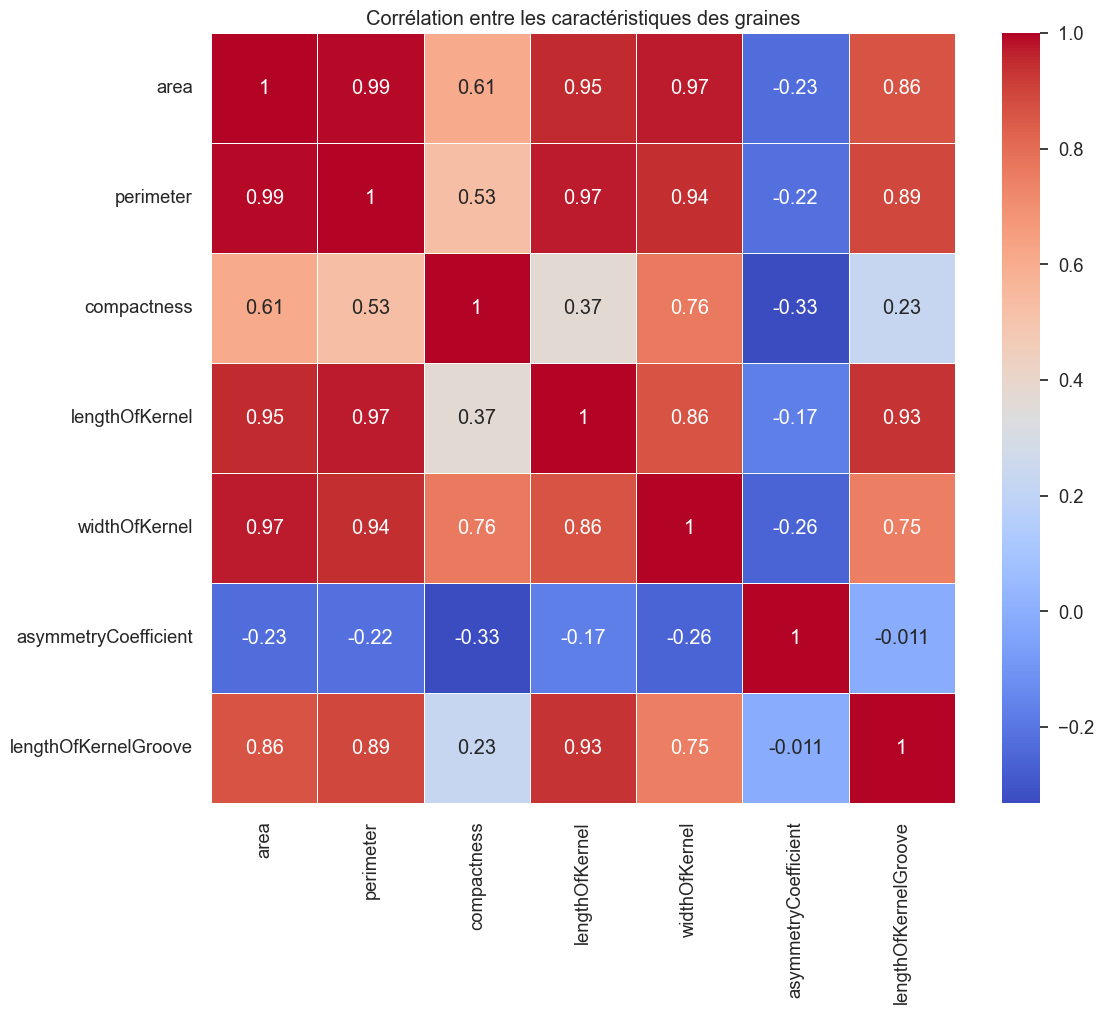

In [15]:
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Corrélation entre les caractéristiques des graines')
plt.savefig('correlation_matrix_graines.png')
plt.show()
plt.close()

Distribution des caractéristiques par type de graine

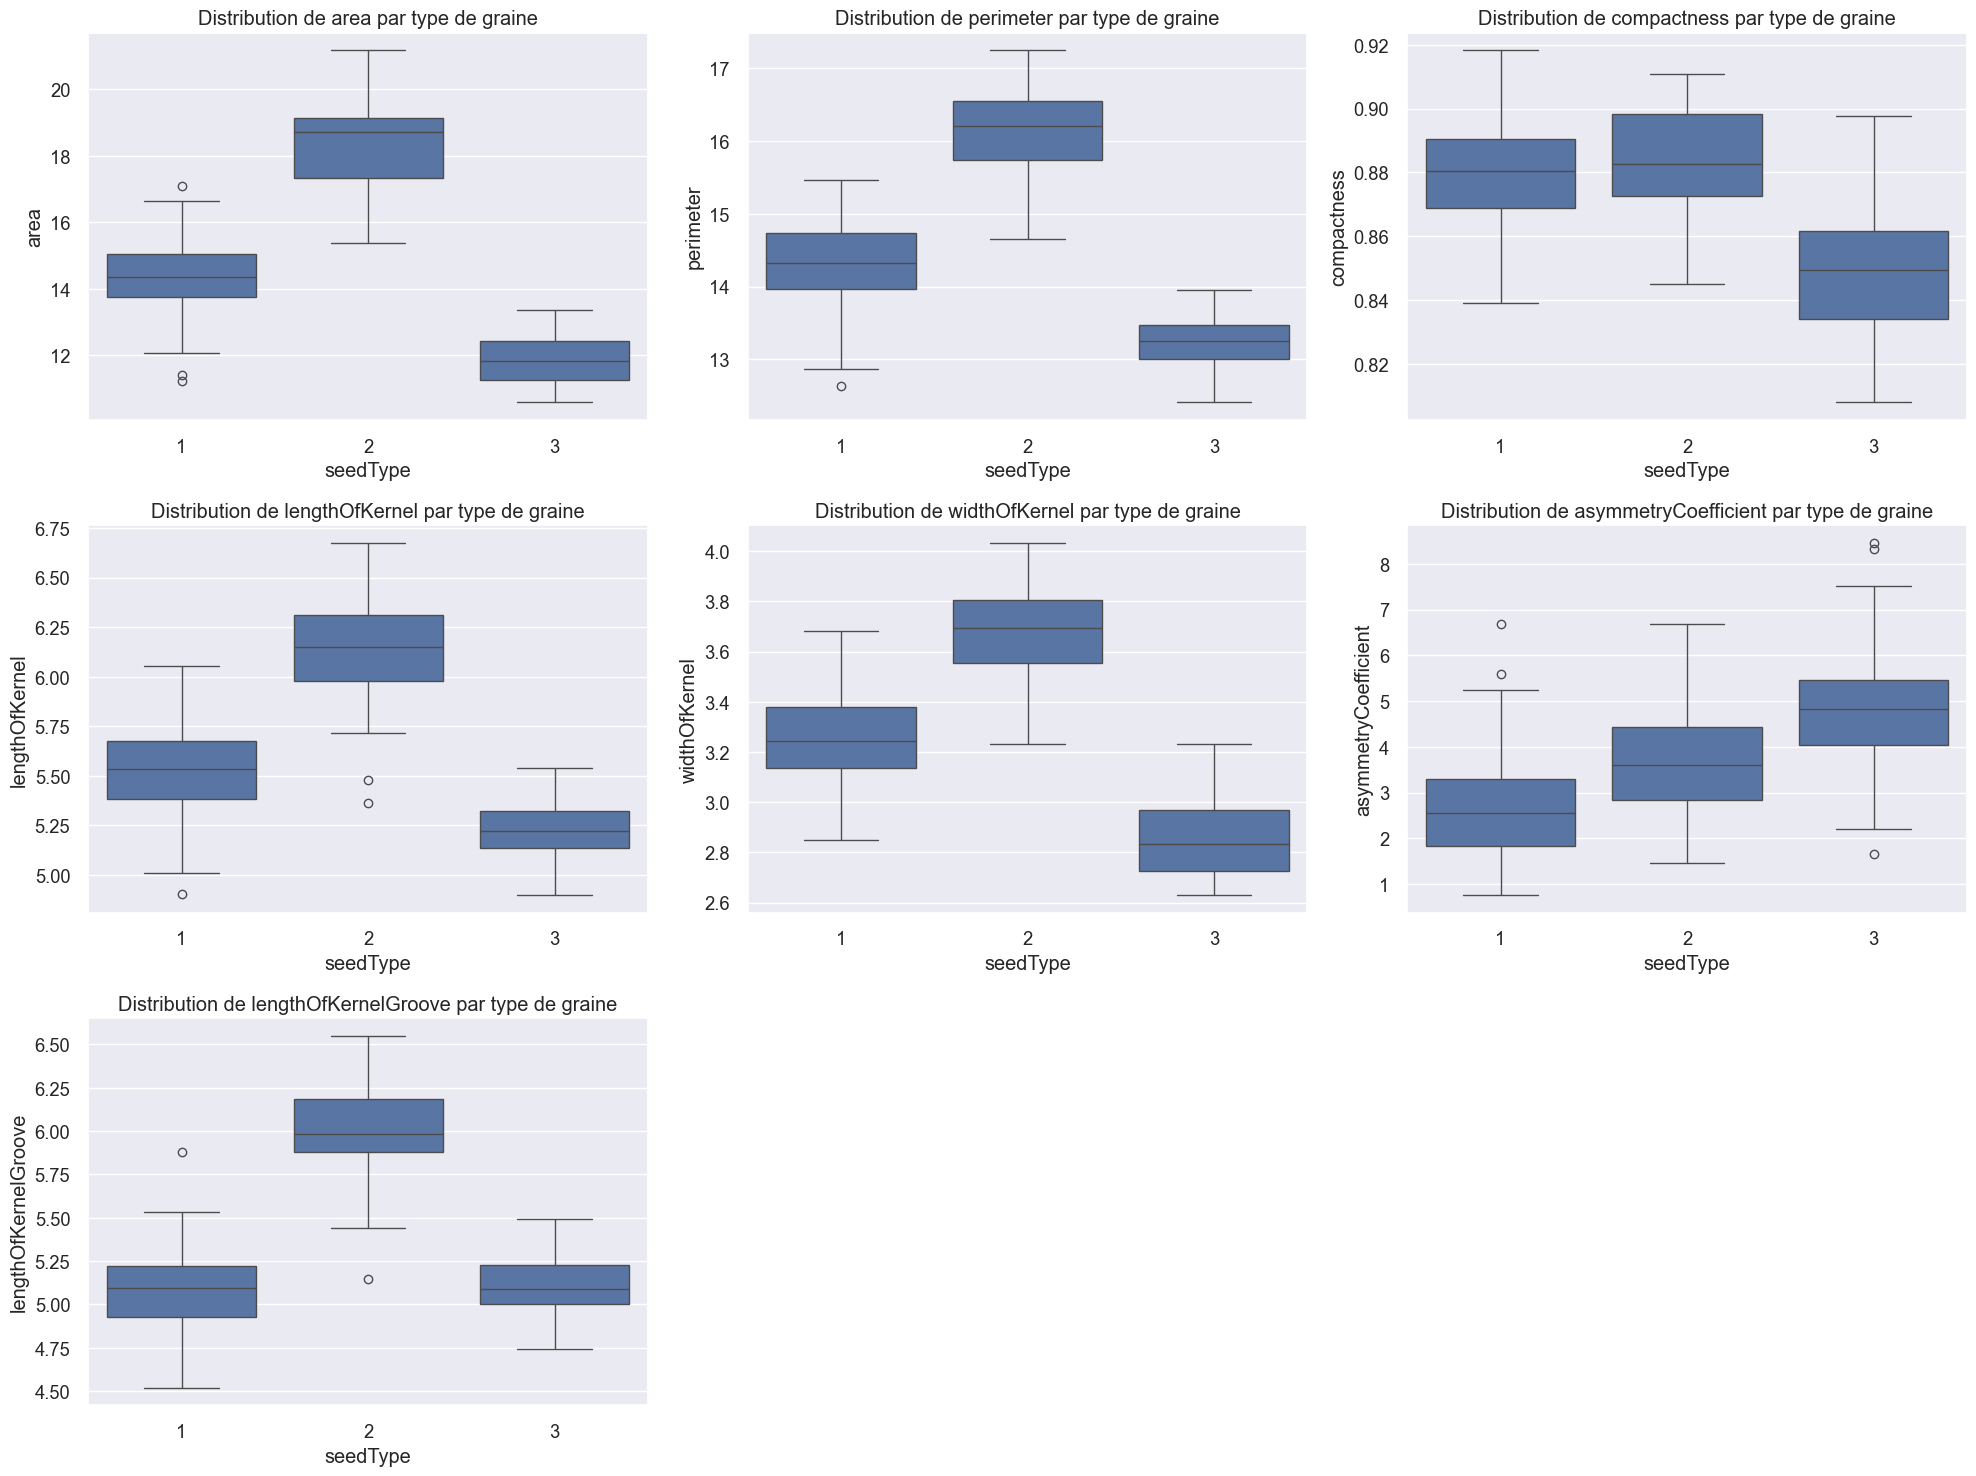

In [16]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='seedType', y=feature, data=df)
    plt.title(f'Distribution de {feature} par type de graine')
plt.tight_layout()
plt.savefig('boxplots_par_type_graine.png')
plt.show()
plt.close()

 Analyse en composantes principales pour visualisation
 

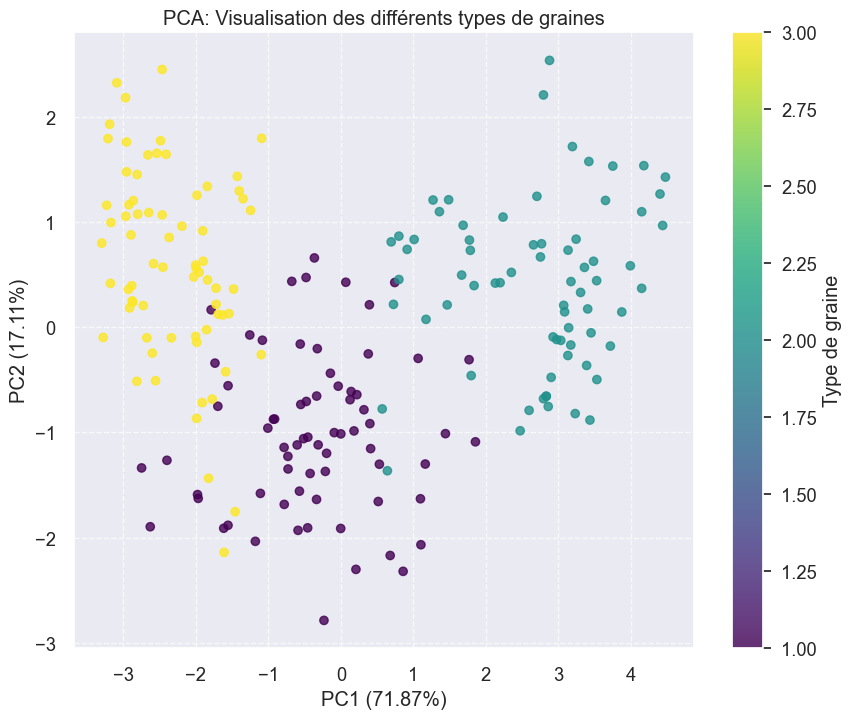

Variance expliquée par les 2 premières composantes principales: 88.98%


In [17]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Type de graine')
plt.title('PCA: Visualisation des différents types de graines')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('pca_visualisation_graines.png')
plt.show()
plt.close()

print(f"Variance expliquée par les 2 premières composantes principales: {sum(pca.explained_variance_ratio_)*100:.2f}%")

 Analyse de clustering non supervisé

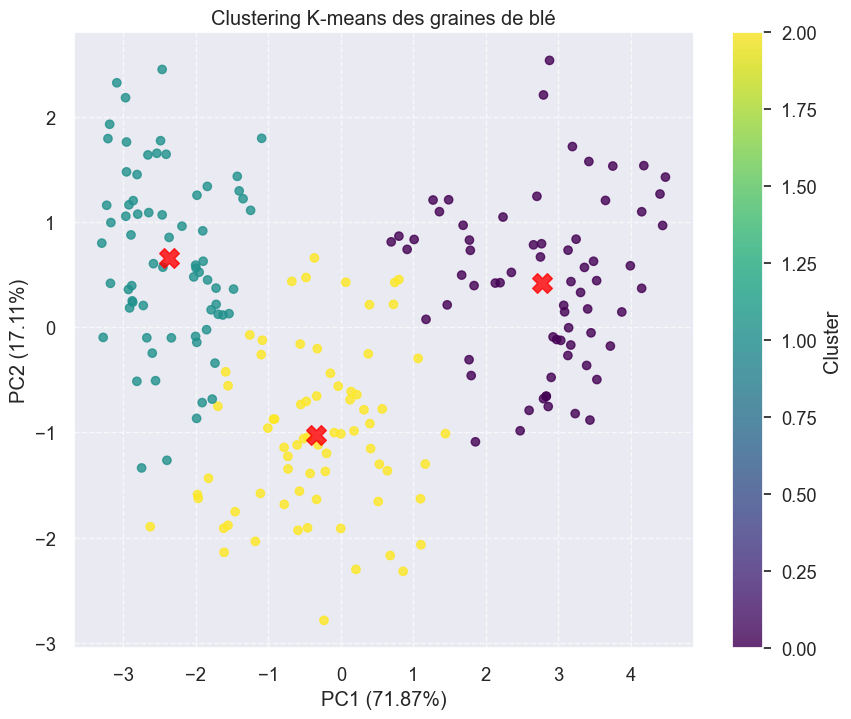

In [18]:
kmeans = KMeans(n_clusters=len(np.unique(y)), random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.8)
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X')
plt.colorbar(scatter, label='Cluster')
plt.title('Clustering K-means des graines de blé')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('kmeans_clustering_graines.png')
plt.show()
plt.close()

 Partitionnement du Dataset

In [19]:
print("\n1.6 Partitionnement du Dataset")
# Séparation en jeux d'entraînement et de test (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Taille du jeu d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille du jeu de test: {X_test.shape[0]} échantillons")



1.6 Partitionnement du Dataset
Taille du jeu d'entraînement: 157 échantillons
Taille du jeu de test: 53 échantillons


# II. Apprentissage

In [20]:
# Fonction pour évaluer et afficher les performances d'un modèle
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Entraînement
    print(f"\nEntraînement du modèle {name}...")
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Évaluation
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # weighted pour multi-classe
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Performance du modèle {name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")
    print("Matrice de confusion:")
    print(conf_matrix)
    
    # Visualisation de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédiction')
    plt.ylabel('Réel')
    plt.title(f'Matrice de confusion - {name}')
    plt.savefig(f'confusion_matrix_graines_{name.replace(" ", "_").lower()}.png')
    plt.show()
    plt.close()
    
    # Afficher le rapport de classification complet
    print("\nRapport de classification:")
    print(classification_report(y_test, y_pred))
    
    # Visualisation des frontières de décision (pour les modèles 2D)
    if X_pca is not None:
        X_train_pca = pca.transform(scaler.transform(X_train))
        X_test_pca = pca.transform(scaler.transform(X_test))
        
        # Entraîner un modèle similaire sur les données PCA
        if name.startswith("K-PPV"):
            pca_model = KNeighborsClassifier(n_neighbors=int(name.split('=')[1].split(')')[0]))
        elif name.startswith("MLP"):
            pca_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
        else:  # SVM
            kernel = name.split('(')[1].split(')')[0]
            pca_model = SVC(kernel=kernel, random_state=42)
        
        pca_model.fit(X_train_pca, y_train)
        
        # Créer une grille pour visualiser les frontières de décision
        h = 0.1  # pas de la grille
        x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
        y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        
        Z = pca_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.figure(figsize=(10, 8))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
        scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', alpha=0.8, edgecolors='k')
        plt.colorbar(scatter, label='Type de graine')
        plt.title(f'Frontières de décision - {name} (PCA)')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
        plt.savefig(f'decision_boundaries_{name.replace(" ", "_").lower()}.png')
        plt.show()
        plt.close()
    
    return accuracy, f1, conf_matrix, model

K-PPV (k=5)


2.1 Classification avec K-PPV (k=5)

Entraînement du modèle K-PPV (k=5)...
Performance du modèle K-PPV (k=5):
Accuracy: 0.8868
F1 Score (weighted): 0.8868
Matrice de confusion:
[[14  2  1]
 [ 2 16  0]
 [ 1  0 17]]


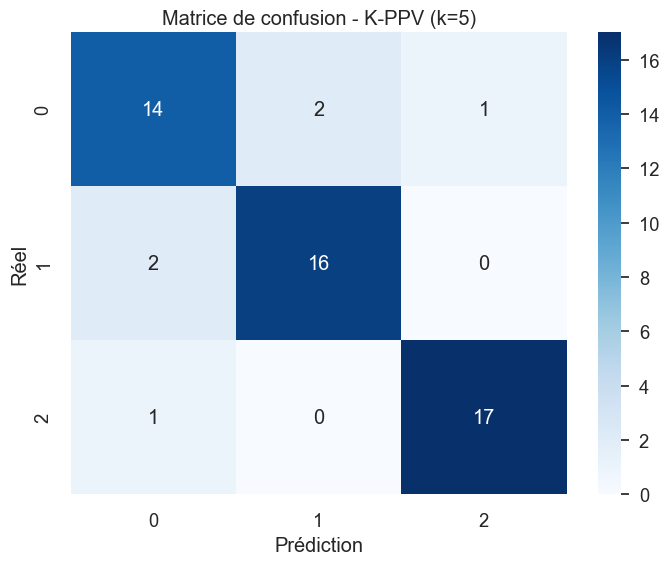


Rapport de classification:
              precision    recall  f1-score   support

           1       0.82      0.82      0.82        17
           2       0.89      0.89      0.89        18
           3       0.94      0.94      0.94        18

    accuracy                           0.89        53
   macro avg       0.89      0.89      0.89        53
weighted avg       0.89      0.89      0.89        53



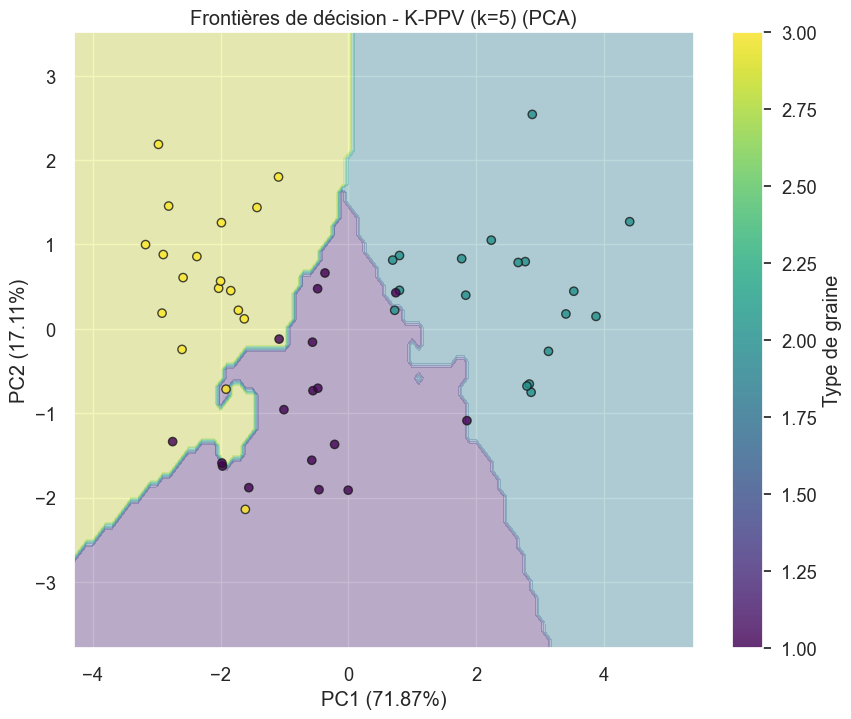

In [21]:
print("\n2.1 Classification avec K-PPV (k=5)")
# Pipeline pour K-PPV avec k=5
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Évaluation du modèle K-PPV avec k=5
knn_accuracy, knn_f1, knn_cm, knn_model = evaluate_model("K-PPV (k=5)", knn_pipeline, X_train, X_test, y_train, y_test)

Variation de k et analyse des résultats


Variation de k et analyse des résultats pour K-PPV:


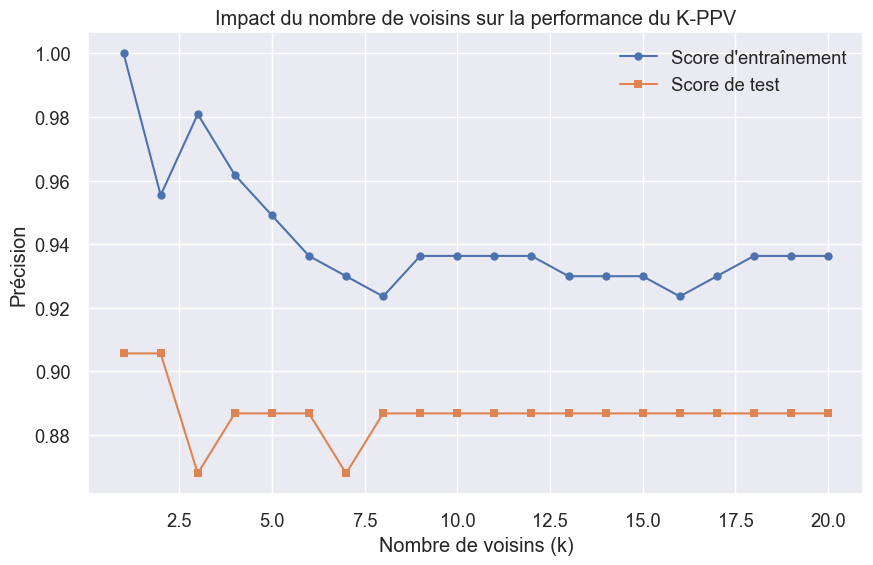

Meilleur k trouvé: 1 avec une précision de 0.9057

Entraînement du modèle K-PPV (k=1)...
Performance du modèle K-PPV (k=1):
Accuracy: 0.9057
F1 Score (weighted): 0.9044
Matrice de confusion:
[[14  1  2]
 [ 2 16  0]
 [ 0  0 18]]


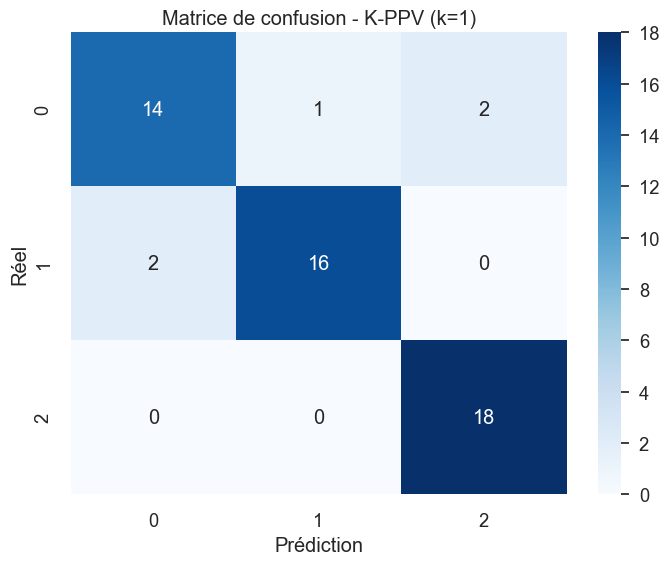


Rapport de classification:
              precision    recall  f1-score   support

           1       0.88      0.82      0.85        17
           2       0.94      0.89      0.91        18
           3       0.90      1.00      0.95        18

    accuracy                           0.91        53
   macro avg       0.91      0.90      0.90        53
weighted avg       0.91      0.91      0.90        53



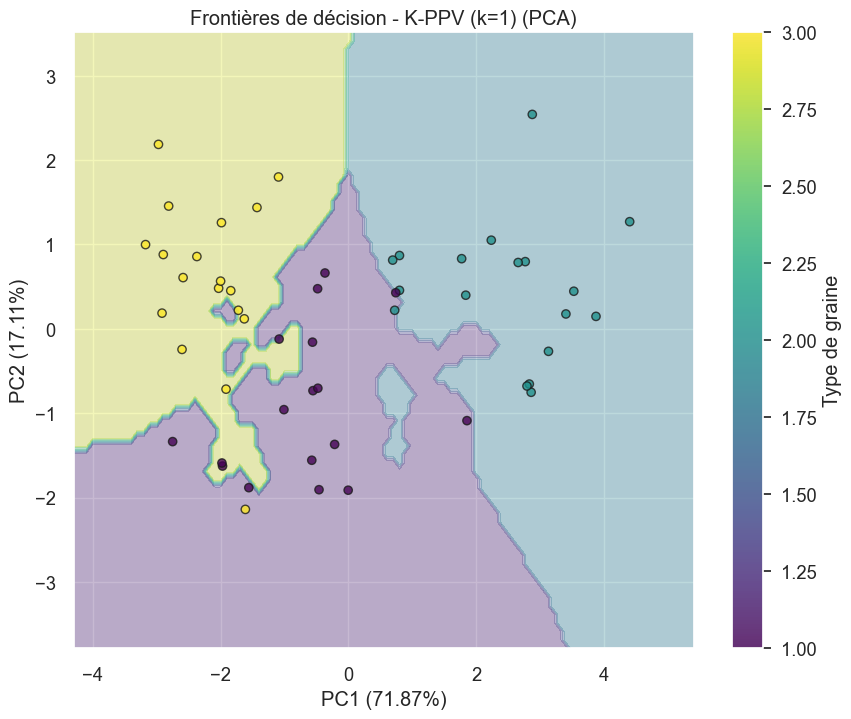

In [22]:
print("\nVariation de k et analyse des résultats pour K-PPV:")
k_values = list(range(1, 21))
train_scores = []
test_scores = []

for k in k_values:
    knn = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

# Visualisation de l'impact de k sur les performances
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Score d\'entraînement')
plt.plot(k_values, test_scores, 's-', label='Score de test')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Précision')
plt.title('Impact du nombre de voisins sur la performance du K-PPV')
plt.legend()
plt.grid(True)
plt.savefig('knn_k_analysis_graines.png')
plt.show()
plt.close()

# Détermination du meilleur k
best_k = k_values[np.argmax(test_scores)]
print(f"Meilleur k trouvé: {best_k} avec une précision de {max(test_scores):.4f}")

# Réévaluation avec le meilleur k
knn_best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

knn_best_accuracy, knn_best_f1, knn_best_cm, knn_best_model = evaluate_model(
    f"K-PPV (k={best_k})", knn_best_pipeline, X_train, X_test, y_train, y_test
)

 Multi-Layer Perceptron (MLP)

 Classification avec Multi-Layer Perceptron (MLP)

Entraînement du modèle MLP...
Performance du modèle MLP:
Accuracy: 0.9057
F1 Score (weighted): 0.9067
Matrice de confusion:
[[15  2  0]
 [ 2 16  0]
 [ 1  0 17]]


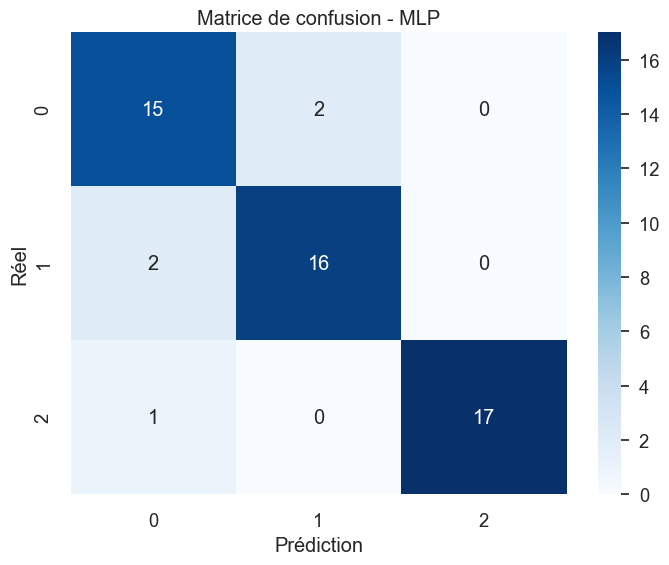


Rapport de classification:
              precision    recall  f1-score   support

           1       0.83      0.88      0.86        17
           2       0.89      0.89      0.89        18
           3       1.00      0.94      0.97        18

    accuracy                           0.91        53
   macro avg       0.91      0.91      0.91        53
weighted avg       0.91      0.91      0.91        53



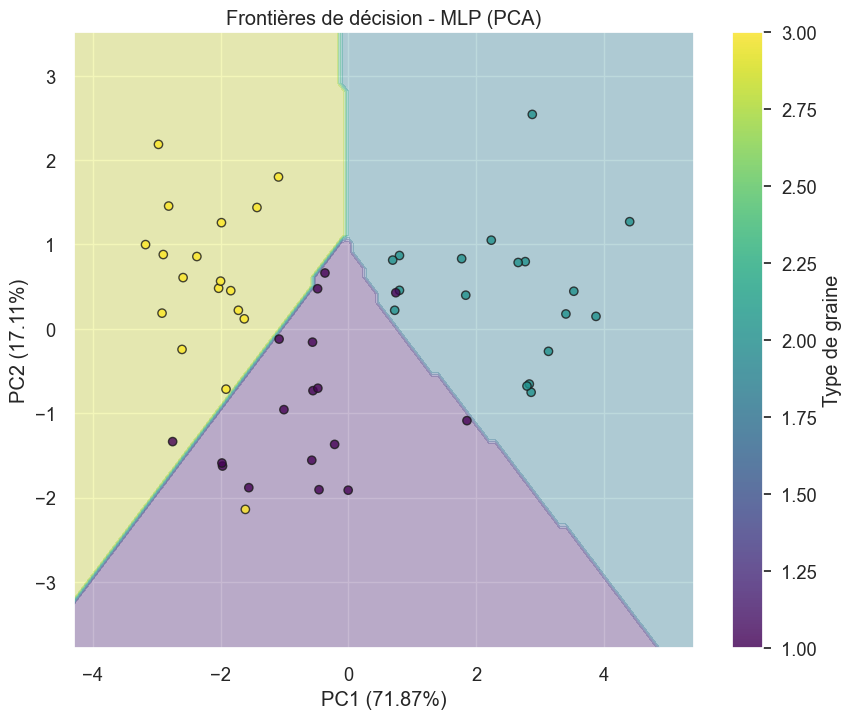


Recherche des meilleurs hyperparamètres pour MLP...
Meilleurs paramètres pour MLP: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (100, 50), 'classifier__learning_rate': 'constant'}
Meilleur score F1 (CV): 0.9680

Entraînement du modèle MLP (meilleurs paramètres)...
Performance du modèle MLP (meilleurs paramètres):
Accuracy: 0.9057
F1 Score (weighted): 0.9067
Matrice de confusion:
[[15  2  0]
 [ 2 16  0]
 [ 1  0 17]]


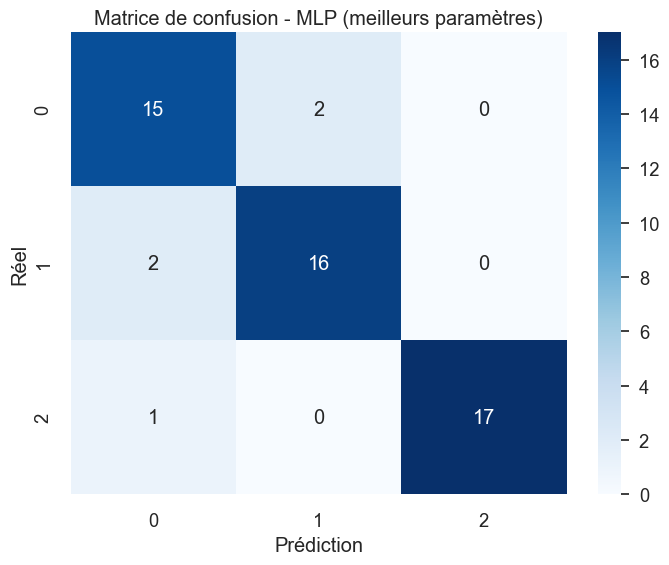


Rapport de classification:
              precision    recall  f1-score   support

           1       0.83      0.88      0.86        17
           2       0.89      0.89      0.89        18
           3       1.00      0.94      0.97        18

    accuracy                           0.91        53
   macro avg       0.91      0.91      0.91        53
weighted avg       0.91      0.91      0.91        53



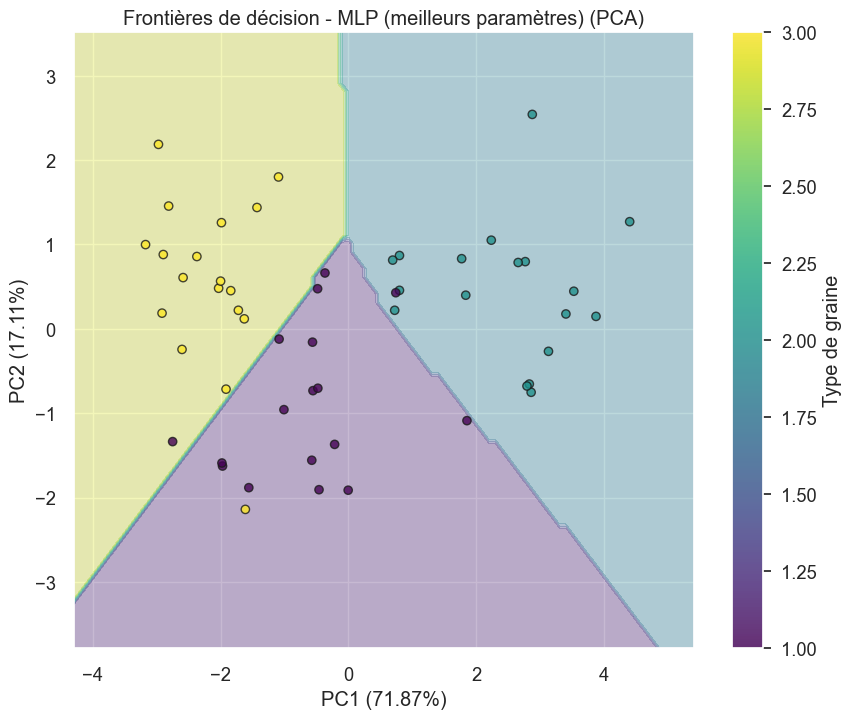

In [23]:

print(" Classification avec Multi-Layer Perceptron (MLP)")
# Pipeline pour MLP avec des paramètres par défaut
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
])

# Évaluation du modèle MLP
mlp_accuracy, mlp_f1, mlp_cm, mlp_model = evaluate_model("MLP", mlp_pipeline, X_train, X_test, y_train, y_test)

# Recherche des meilleurs hyperparamètres pour MLP
print("\nRecherche des meilleurs hyperparamètres pour MLP...")
param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate': ['constant', 'adaptive']
}

grid_search_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_mlp.fit(X_train, y_train)

print(f"Meilleurs paramètres pour MLP: {grid_search_mlp.best_params_}")
print(f"Meilleur score F1 (CV): {grid_search_mlp.best_score_:.4f}")

# Réévaluation avec les meilleurs paramètres
mlp_best_accuracy, mlp_best_f1, mlp_best_cm, mlp_best_model = evaluate_model(
    "MLP (meilleurs paramètres)", grid_search_mlp.best_estimator_, X_train, X_test, y_train, y_test
)

SVM avec différents noyaux

Classification avec SVM (différents noyaux)

Entraînement SVM avec noyau rbf
Meilleurs paramètres pour SVM avec noyau rbf:
{'classifier__C': 10, 'classifier__gamma': 0.1}
Meilleur score F1 (CV): 0.9558

Entraînement du modèle SVM (rbf)...
Performance du modèle SVM (rbf):
Accuracy: 0.8868
F1 Score (weighted): 0.8867
Matrice de confusion:
[[14  1  2]
 [ 2 16  0]
 [ 1  0 17]]


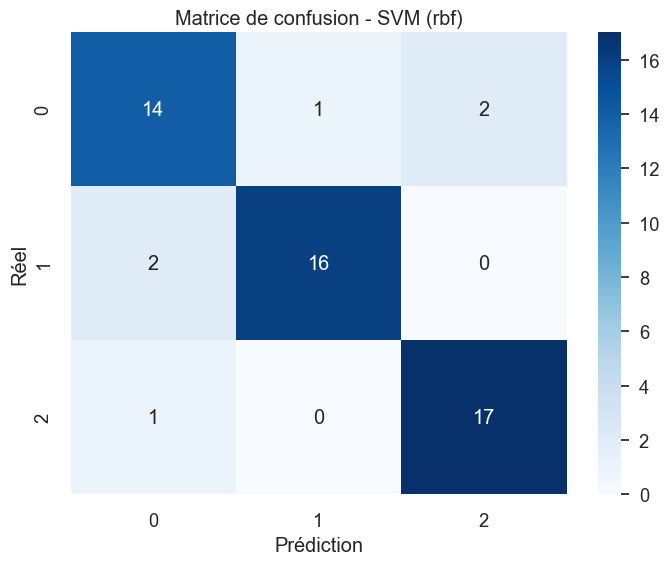


Rapport de classification:
              precision    recall  f1-score   support

           1       0.82      0.82      0.82        17
           2       0.94      0.89      0.91        18
           3       0.89      0.94      0.92        18

    accuracy                           0.89        53
   macro avg       0.89      0.89      0.89        53
weighted avg       0.89      0.89      0.89        53



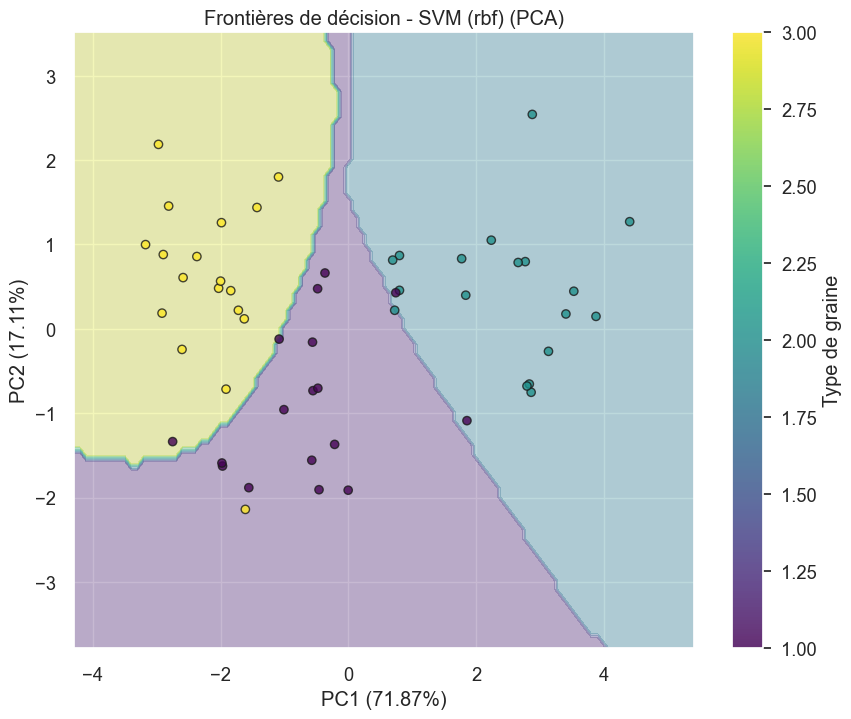


Entraînement SVM avec noyau poly
Meilleurs paramètres pour SVM avec noyau poly:
{'classifier__C': 10, 'classifier__degree': 3, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): 0.8995

Entraînement du modèle SVM (poly)...
Performance du modèle SVM (poly):
Accuracy: 0.8679
F1 Score (weighted): 0.8690
Matrice de confusion:
[[15  1  1]
 [ 4 14  0]
 [ 1  0 17]]


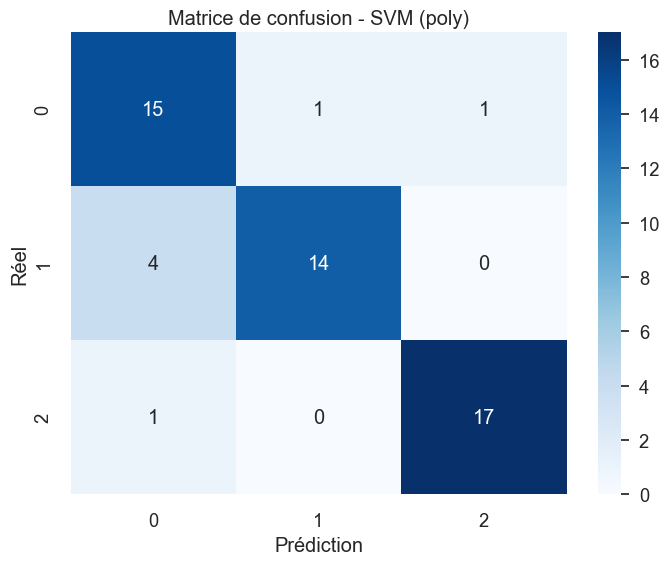


Rapport de classification:
              precision    recall  f1-score   support

           1       0.75      0.88      0.81        17
           2       0.93      0.78      0.85        18
           3       0.94      0.94      0.94        18

    accuracy                           0.87        53
   macro avg       0.88      0.87      0.87        53
weighted avg       0.88      0.87      0.87        53



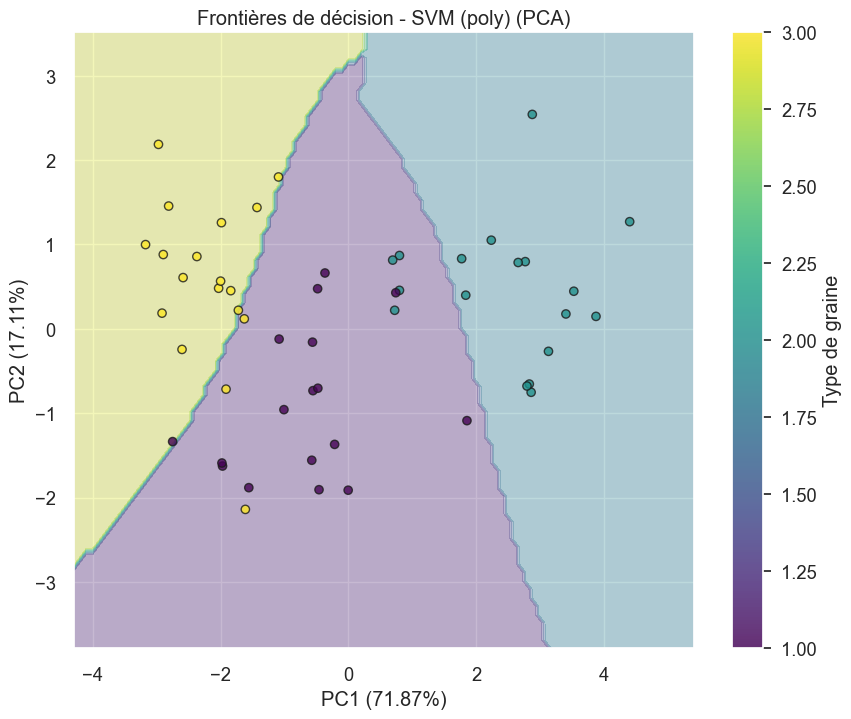


Entraînement SVM avec noyau sigmoid
Meilleurs paramètres pour SVM avec noyau sigmoid:
{'classifier__C': 10, 'classifier__gamma': 0.1}
Meilleur score F1 (CV): 0.9421

Entraînement du modèle SVM (sigmoid)...
Performance du modèle SVM (sigmoid):
Accuracy: 0.8868
F1 Score (weighted): 0.8867
Matrice de confusion:
[[14  1  2]
 [ 2 16  0]
 [ 1  0 17]]


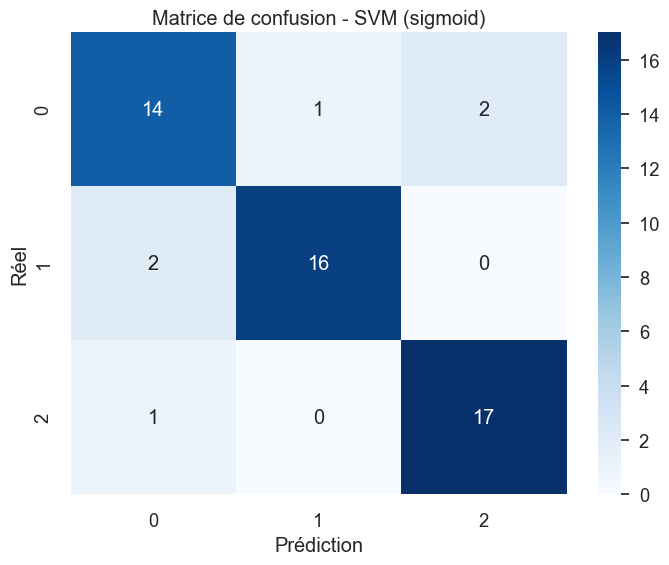


Rapport de classification:
              precision    recall  f1-score   support

           1       0.82      0.82      0.82        17
           2       0.94      0.89      0.91        18
           3       0.89      0.94      0.92        18

    accuracy                           0.89        53
   macro avg       0.89      0.89      0.89        53
weighted avg       0.89      0.89      0.89        53



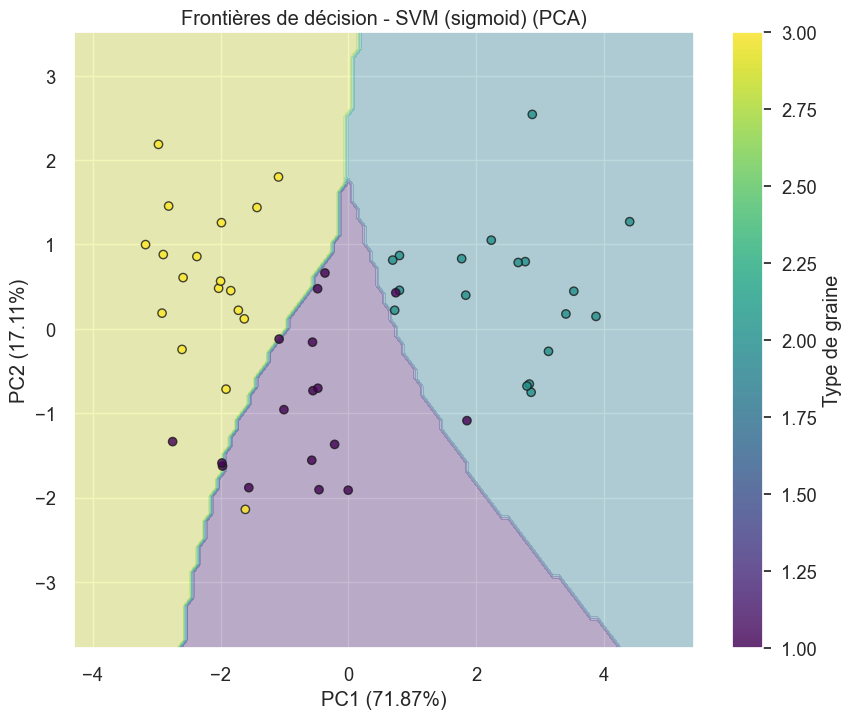


Meilleur noyau SVM: rbf
F1 Score: 0.8867
Paramètres: {'classifier__C': 10, 'classifier__gamma': 0.1}


In [24]:
print("Classification avec SVM (différents noyaux)")

# Pour chaque type de noyau, définir une plage d'hyperparamètres à tester
kernels = ['rbf', 'poly', 'sigmoid']
svm_results = {}

for kernel in kernels:
    print(f"\nEntraînement SVM avec noyau {kernel}")
    
    # Définir les paramètres de recherche pour chaque noyau
    if kernel == 'rbf':
        param_grid = {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        }
    elif kernel == 'poly':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__degree': [2, 3, 4],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
        }
    elif kernel == 'sigmoid':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        }
    
    # Définir le pipeline avec le noyau actuel
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel=kernel, random_state=42))
    ])
    
    # Recherche par validation croisée
    grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Meilleurs paramètres pour SVM avec noyau {kernel}:")
    print(grid_search.best_params_)
    print(f"Meilleur score F1 (CV): {grid_search.best_score_:.4f}")
    
    # Évaluer le modèle avec les meilleurs paramètres
    accuracy, f1, cm, model = evaluate_model(
        f"SVM ({kernel})", grid_search.best_estimator_, X_train, X_test, y_train, y_test
    )
    
    svm_results[kernel] = {
        'accuracy': accuracy,
        'f1': f1,
        'model': model,
        'best_params': grid_search.best_params_
    }

# Déterminer le meilleur noyau SVM
best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['f1'])
print(f"\nMeilleur noyau SVM: {best_kernel}")
print(f"F1 Score: {svm_results[best_kernel]['f1']:.4f}")
print(f"Paramètres: {svm_results[best_kernel]['best_params']}")


# III. Évaluation comparative des performances

Comparaison des performances:
                   Modèle  Accuracy  F1 Score
0             K-PPV (k=1)  0.905660  0.904415
1  MLP (meilleurs params)  0.905660  0.906739
2               SVM (rbf)  0.886792  0.886749
3              SVM (poly)  0.867925  0.868991
4           SVM (sigmoid)  0.886792  0.886749


<Figure size 1200x600 with 0 Axes>

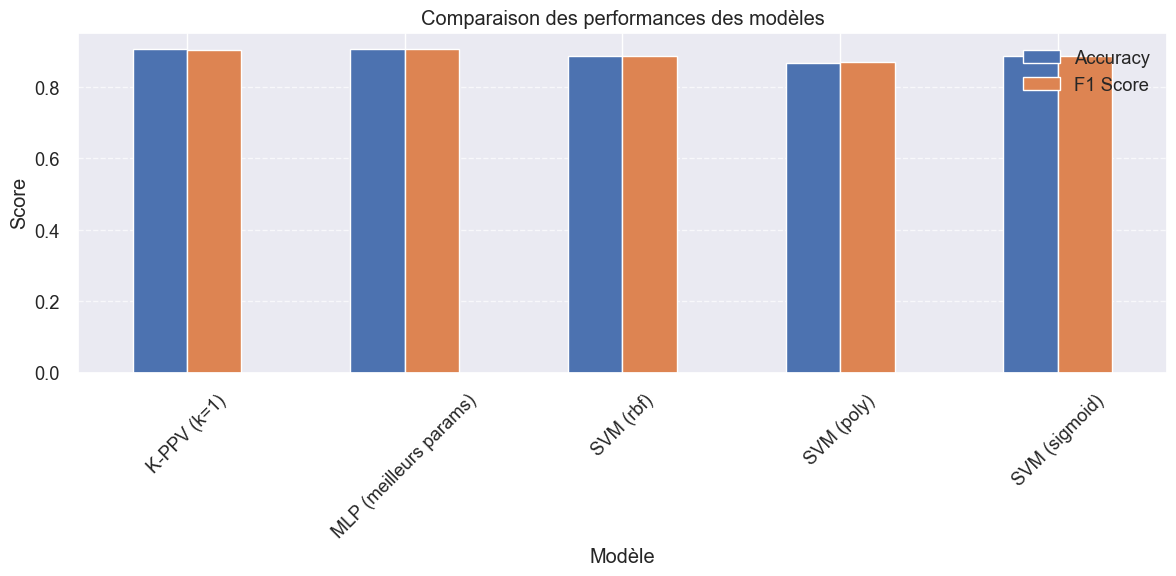


Meilleur modèle global: MLP (meilleurs params)
F1 Score: 0.9067
Accuracy: 0.9057

IV. ANALYSE DE L'IMPORTANCE DES CARACTÉRISTIQUES
Importance des caractéristiques basée sur la corrélation avec la variable cible:
asymmetryCoefficient: 0.5773
compactness: 0.5310
widthOfKernel: 0.4235
area: 0.3461
perimeter: 0.3279
lengthOfKernel: 0.2573
lengthOfKernelGroove: 0.0243


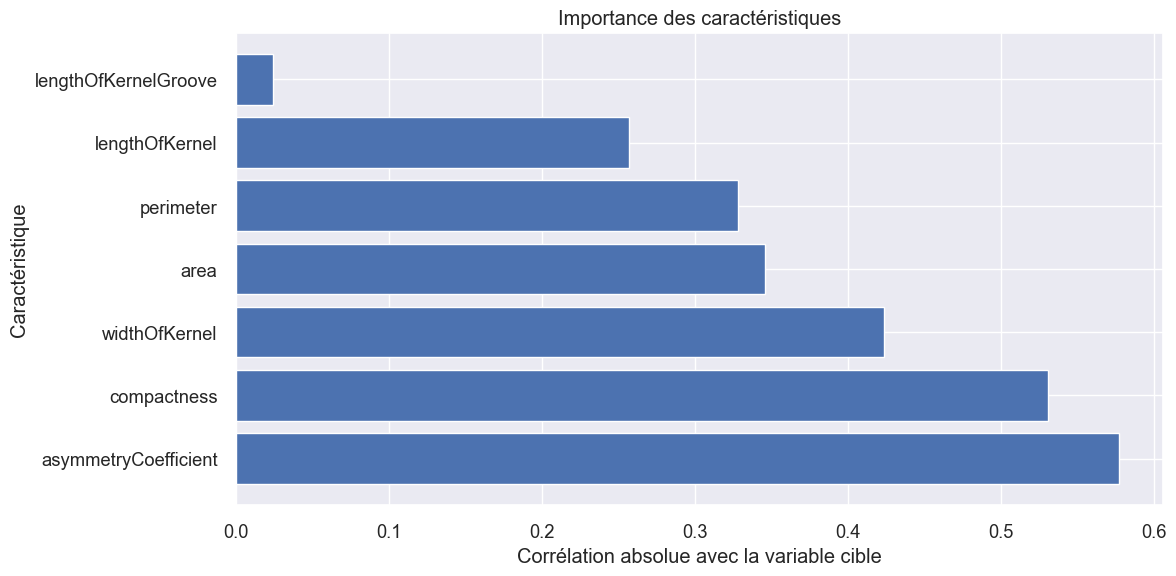


Analyse de l'importance des caractéristiques par exclusion:
Importance des caractéristiques basée sur l'exclusion (pour MLP (meilleurs params)):
lengthOfKernelGroove: 0.0566
area: 0.0000
perimeter: 0.0000
compactness: 0.0000
lengthOfKernel: 0.0000
widthOfKernel: 0.0000
asymmetryCoefficient: 0.0000


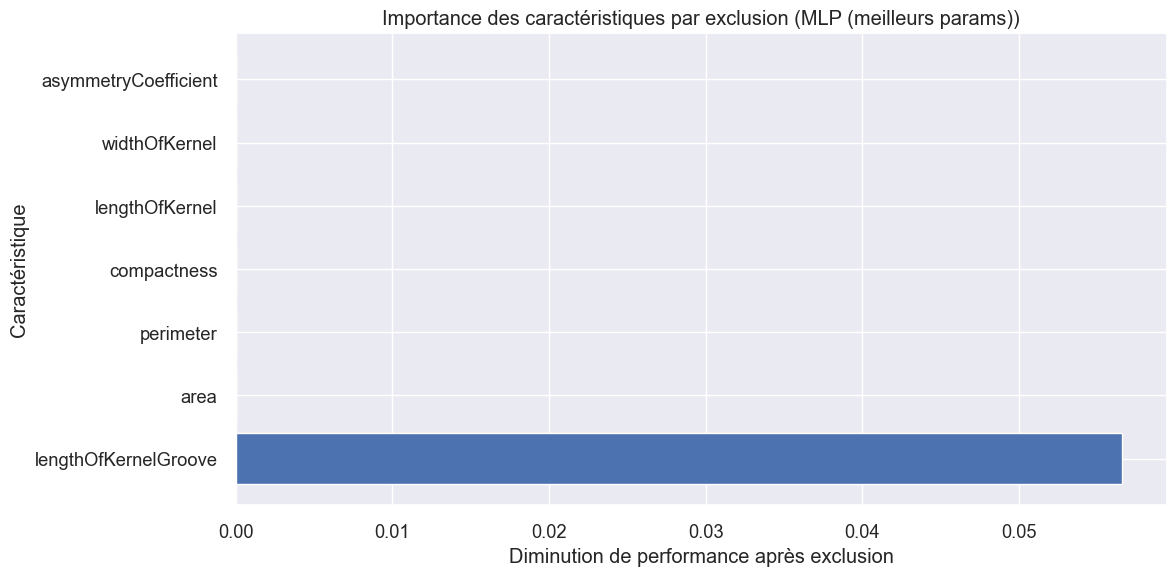

Le meilleur modèle est MLP (meilleurs params) avec:
- F1 Score: 0.9067
- Accuracy: 0.9057

Caractéristiques les plus importantes pour la classification des graines:
- lengthOfKernelGroove (impact: 0.0566)
- area (impact: 0.0000)
- perimeter (impact: 0.0000)
Recommandations:
 Utiliser le modèle MLP (meilleurs params) pour la classification des graines de blé
Se concentrer sur les mesures de lengthOfKernelGroove, area, perimeter pour l'identification rapide des types de graines


In [25]:

# Collecter les résultats de tous les modèles
models_results = {
    f"K-PPV (k={best_k})": {'accuracy': knn_best_accuracy, 'f1': knn_best_f1},
    "MLP (meilleurs params)": {'accuracy': mlp_best_accuracy, 'f1': mlp_best_f1}
}

for kernel in svm_results:
    models_results[f"SVM ({kernel})"] = {
        'accuracy': svm_results[kernel]['accuracy'], 
        'f1': svm_results[kernel]['f1']
    }

# Créer un DataFrame pour la comparaison
comparison_df = pd.DataFrame({
    'Modèle': list(models_results.keys()),
    'Accuracy': [models_results[model]['accuracy'] for model in models_results],
    'F1 Score': [models_results[model]['f1'] for model in models_results]
})

print("Comparaison des performances:")
print(comparison_df)

# Visualisation des performances
plt.figure(figsize=(12, 6))
comparison_df.set_index('Modèle').plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des performances des modèles')
plt.ylabel('Score')
plt.xlabel('Modèle')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('model_comparison_graines.png')
plt.show()
plt.close()

# Déterminer le meilleur modèle global
best_model_name = max(models_results.keys(), key=lambda k: models_results[k]['f1'])
print(f"\nMeilleur modèle global: {best_model_name}")
print(f"F1 Score: {models_results[best_model_name]['f1']:.4f}")
print(f"Accuracy: {models_results[best_model_name]['accuracy']:.4f}")

# IV. Analyse de l'importance des caractéristiques
print("\nIV. ANALYSE DE L'IMPORTANCE DES CARACTÉRISTIQUES")
print("=============================================")

# Analyse de l'importance des caractéristiques basée sur la corrélation avec la variable cible
target_correlation = {}
df_with_target = pd.concat([X, pd.Series(y, name='target')], axis=1)

for feature in features:
    correlation = df_with_target[feature].corr(df_with_target['target'])
    target_correlation[feature] = abs(correlation)  # Valeur absolue car nous nous intéressons à l'importance, pas à la direction

# Trier les caractéristiques par importance de corrélation
sorted_features = sorted(target_correlation.items(), key=lambda x: x[1], reverse=True)

print("Importance des caractéristiques basée sur la corrélation avec la variable cible:")
for feature, importance in sorted_features:
    print(f"{feature}: {importance:.4f}")

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(12, 6))
features_names, importances = zip(*sorted_features)
plt.barh(features_names, importances)
plt.xlabel('Corrélation absolue avec la variable cible')
plt.ylabel('Caractéristique')
plt.title('Importance des caractéristiques')
plt.tight_layout()
plt.savefig('feature_importance_graines.png')
plt.show()
plt.close()

# Analyse basée sur l'exclusion de caractéristiques (pour le meilleur modèle)
print("\nAnalyse de l'importance des caractéristiques par exclusion:")

# Choisir le meilleur modèle pour l'analyse d'importance
if best_model_name.startswith("K-PPV"):
    base_estimator = KNeighborsClassifier(n_neighbors=best_k)
elif best_model_name.startswith("MLP"):
    base_params = {k.replace('classifier__', ''): v for k, v in grid_search_mlp.best_params_.items()}
    base_estimator = MLPClassifier(**base_params)
else:  # SVM
    kernel = best_model_name.split('(')[1].split(')')[0]
    base_params = {k.replace('classifier__', ''): v for k, v in svm_results[kernel]['best_params'].items()}
    base_estimator = SVC(kernel=kernel, **base_params)

# Évaluer l'importance par la diminution de performance
exclusion_importance = {}
baseline_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', base_estimator)])
baseline_pipeline.fit(X_train, y_train)
baseline_score = accuracy_score(y_test, baseline_pipeline.predict(X_test))

for feature in features:
    # Entrainer sans cette caractéristique
    X_train_reduced = X_train.drop(feature, axis=1)
    X_test_reduced = X_test.drop(feature, axis=1)
    
    reduced_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', base_estimator)])
    reduced_pipeline.fit(X_train_reduced, y_train)
    reduced_score = accuracy_score(y_test, reduced_pipeline.predict(X_test_reduced))
    
    # L'importance est la diminution de performance
    exclusion_importance[feature] = baseline_score - reduced_score

# Trier les caractéristiques par importance
sorted_exclusion = sorted(exclusion_importance.items(), key=lambda x: x[1], reverse=True)

print(f"Importance des caractéristiques basée sur l'exclusion (pour {best_model_name}):")
for feature, importance in sorted_exclusion:
    print(f"{feature}: {importance:.4f}")

# Visualiser l'importance des caractéristiques par exclusion
plt.figure(figsize=(12, 6))
features_names, importances = zip(*sorted_exclusion)
plt.barh(features_names, importances)
plt.xlabel('Diminution de performance après exclusion')
plt.ylabel('Caractéristique')
plt.title(f'Importance des caractéristiques par exclusion ({best_model_name})')
plt.tight_layout()
plt.savefig('feature_importance_exclusion_graines.png')
plt.show()
plt.close()


print(f"Le meilleur modèle est {best_model_name} avec:")
print(f"- F1 Score: {models_results[best_model_name]['f1']:.4f}")
print(f"- Accuracy: {models_results[best_model_name]['accuracy']:.4f}")

print("\nCaractéristiques les plus importantes pour la classification des graines:")
for feature, importance in sorted_exclusion[:3]:
    print(f"- {feature} (impact: {importance:.4f})")

print("Recommandations:")
print(" Utiliser le modèle " + best_model_name + " pour la classification des graines de blé")
print("Se concentrer sur les mesures de " + ", ".join([f[0] for f in sorted_exclusion[:3]]) + " pour l'identification rapide des types de graines")